In [172]:
import glob
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Set your run directory here
# Example: ../results/20260223_052810_balanced
# -----------------------------

RUN_DIR = Path("../results/20260224_010612_skew").resolve()
#RUN_DIR = Path("../results/20260223_052810_balanced").resolve()

CONSUMER_DIR = RUN_DIR / "consumer"
CFG_PATH = CONSUMER_DIR / "pipeline-configmap.yaml"

# CSVs produced by consumer metrics
FILES = sorted(CONSUMER_DIR.glob("consumer-sts-*_metrics/consumer_metrics_run-*_consumer-sts-*.csv"))

if not FILES:
    raise FileNotFoundError(
        "No consumer metrics CSV files found. "
        "Check RUN_DIR and the consumer-sts-*metrics folder structure."
    )

def _read_pipeline_cfg(cfg_path: Path) -> dict:
    """Read the YAML ConfigMap file saved alongside results and extract run metadata.

    Expected location:
      results/<date>_<time>_<mode>/consumer/pipeline-configmap.yaml

    Returns a dict with keys:
      traffic_mode (str), skew_fraction (float|None), skew_partitions (str)
    """
    meta = {"traffic_mode": "unknown", "skew_fraction": None, "skew_partitions": "unknown"}

    if not cfg_path.exists():
        return meta

    try:
        import yaml  # PyYAML
        with cfg_path.open("r", encoding="utf-8") as f:
            y = yaml.safe_load(f) or {}
        data = (y.get("data") or {})
    except Exception:
        return meta

    # Common keys you used in your pipeline ConfigMap
    tm = data.get("TRAFFIC_MODE", data.get("traffic_mode", "unknown"))
    sf = data.get("SKEW_FRACTION", data.get("skew_fraction", None))
    sp = data.get("SKEW_PARTITIONS", data.get("SKEW_PARTITION", data.get("skew_partitions", None)))

    # Normalize strings
    if isinstance(tm, str):
        tm = tm.strip().lower()
    else:
        tm = str(tm).strip().lower()

    # Normalize skew fraction
    if sf is not None:
        try:
            sf = float(str(sf).strip())
        except Exception:
            sf = None

    # Normalize skew partitions to a short string for titles/file names
    if sp is None:
        sp_str = "unknown"
    elif isinstance(sp, (list, tuple)):
        sp_str = ",".join(str(x).strip() for x in sp)
    else:
        sp_str = str(sp).strip()

    meta["traffic_mode"] = tm if tm else "unknown"
    meta["skew_fraction"] = sf
    meta["skew_partitions"] = sp_str if sp_str else "unknown"
    return meta

RUN_META = _read_pipeline_cfg(CFG_PATH)

# Derive a compact tag used in titles and output file names
run_id = RUN_DIR.name
tm = RUN_META["traffic_mode"]
sf = RUN_META["skew_fraction"]
sp = RUN_META["skew_partitions"]

sf_tag = "na" if sf is None else f"{sf:g}"
tag = f"{run_id}_tm-{tm}_sf-{sf_tag}_sp-{sp}".replace("/", "-").replace(" ", "")


In [173]:
print("RUN_DIR:", RUN_DIR)
print("Config:", CFG_PATH if CFG_PATH.exists() else "(missing)")
print("traffic_mode:", RUN_META["traffic_mode"])
print("skew_fraction:", RUN_META["skew_fraction"])
print("skew_partitions:", RUN_META["skew_partitions"])
print("tag:", tag)


RUN_DIR: /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/20260224_010612_skew
Config: /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/20260224_010612_skew/consumer/pipeline-configmap.yaml
traffic_mode: skew
skew_fraction: 0.3
skew_partitions: 0
tag: 20260224_010612_skew_tm-skew_sf-0.3_sp-0


In [174]:

def pod_from_name(path: str) -> str:
    m = re.search(r"(consumer-sts-\d+)", os.path.basename(path))
    return m.group(1) if m else "unknown"


In [177]:
# 1) load + concat
dfs = []
for f in FILES:
    df = pd.read_csv(f)
    if "pod" not in df.columns:
        df["pod"] = pod_from_name(str(f))
    df["file"] = f.name

    # numeric coercion (skip known string cols)
    for c in df.columns:
        if c in ("pod", "traffic_mode", "topics", "file"):
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data.head()


,pod,traffic_mode,topics,window_total,window_viol,msg_rate_window,lat_window_seconds,lat_count_window,lat_p95_ms,lat_p99_ms,cpu_percent,mem_percent,uptime_sec,total_lag,max_lag,lag_skew_ratio,consumed_total,file
0,consumer-sts-0,skew,B0-R100-20260224-003716_0,370,27,6.166667,30.0,370,1436.528,3053.327,0.0,14.6,30.031,0.0,0.0,0.000000,370,consumer_metrics_run-20260224-003716_consumer-...
1,consumer-sts-0,skew,B0-R100-20260224-003716_0,1206,43,20.100000,30.0,835,559.423,1163.386,7.6,14.6,60.061,24.0,7.0,2.333333,1206,consumer_metrics_run-20260224-003716_consumer-...
2,consumer-sts-0,skew,B0-R100-20260224-003716_0,1663,27,27.716667,30.0,828,455.601,849.276,6.2,14.6,90.092,12.0,3.0,2.000000,2034,consumer_metrics_run-20260224-003716_consumer-...
3,consumer-sts-0,skew,B0-R100-20260224-003716_0,1634,29,27.233333,30.0,806,373.132,1043.126,7.2,14.6,120.121,9.0,4.0,3.555556,2840,consumer_metrics_run-20260224-003716_consumer-...
4,consumer-sts-0,skew,B0-R100-20260224-003716_0,1591,31,26.516667,30.0,779,300.569,924.604,6.1,14.6,150.149,15.0,5.0,2.666667,3619,consumer_metrics_run-20260224-003716_consumer-...


In [178]:
# 2) basic derived columns
data = data.sort_values(["pod", "uptime_sec"]).reset_index(drop=True)
data["viol_rate"] = np.where(data["window_total"] > 0, data["window_viol"] / data["window_total"], np.nan)


In [179]:

# window size (seconds)
win = float(data["lat_window_seconds"].mode().iloc[0])

# bucket uptime (0–29 -> 0, 30–59 -> 30, etc.)
data["t_bucket"] = (np.floor(data["uptime_sec"] / win) * win).astype(int)

cluster = (
    data.groupby("t_bucket", as_index=False)
        .agg(
            pods=("pod", "nunique"),
            throughput=("msg_rate_window", "sum"),
            p99_max=("lat_p99_ms", "max"),
            p99_med=("lat_p99_ms", "median"),
            window_total=("window_total", "sum"),
            window_viol=("window_viol", "sum"),
            total_lag=("total_lag", "sum"),
            max_lag=("max_lag", "max"),
        )
)

cluster["viol_rate"] = np.where(
    cluster["window_total"] > 0,
    cluster["window_viol"] / cluster["window_total"],
    np.nan
)

# print("Pods in merged data:", sorted(data["pod"].unique()))
# print("Pods per bucket (should be 8):", cluster["pods"].value_counts().to_dict())
run_id

'20260224_010612_skew'

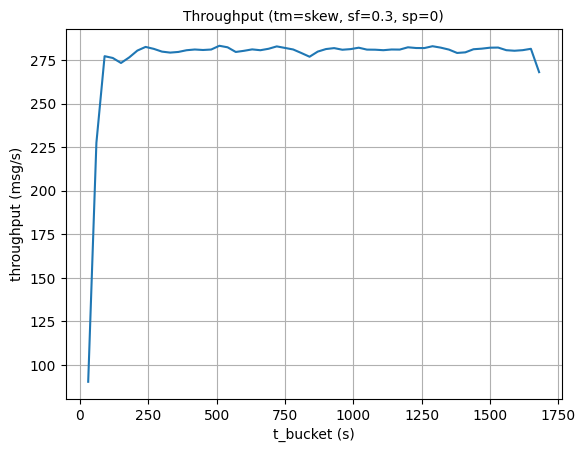

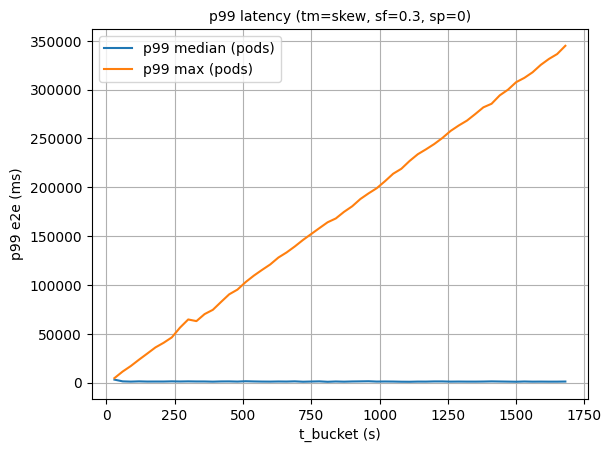

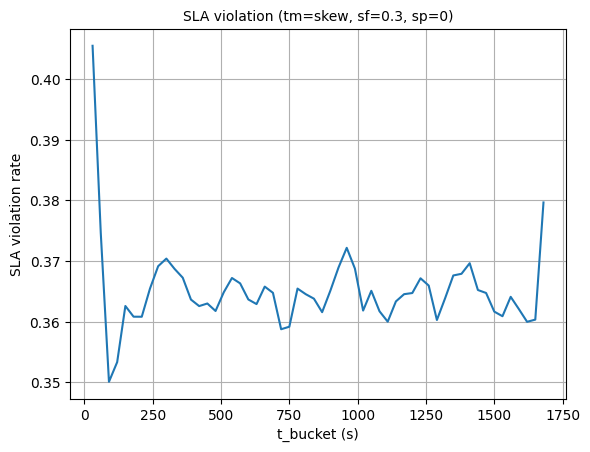

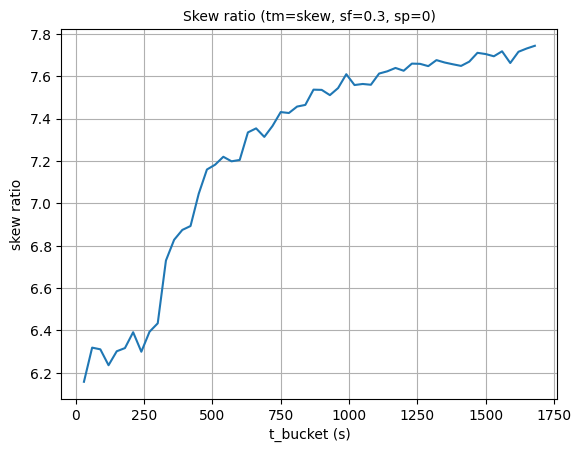

Saved:
 - analysis_out_update/20260224_010612_skew/per_pod_merged_20260224_010612_skew_tm-skew_sf-0.3_sp-0.csv
 - analysis_out_update/20260224_010612_skew/cluster_agg_20260224_010612_skew_tm-skew_sf-0.3_sp-0.csv


In [180]:
from pathlib import Path

out_dir = Path("analysis_out_update") / run_id
out_dir.mkdir(parents=True, exist_ok=True)

# --- Aggregate cluster-level time series ---
# window size (seconds)
win = float(data["lat_window_seconds"].mode().iloc[0])

data["t_bucket"] = (np.floor(data["uptime_sec"] / win) * win).astype(int)

cluster = (
    data.groupby("t_bucket", as_index=False)
        .agg(
            pods=("pod", "nunique"),
            throughput=("msg_rate_window", "sum"),
            p99_max=("lat_p99_ms", "max"),
            p99_med=("lat_p99_ms", "median"),
            window_total=("window_total", "sum"),
            window_viol=("window_viol", "sum"),
            total_lag=("total_lag", "sum"),
            max_lag=("max_lag", "max"),
        )
)

cluster["viol_rate"] = np.where(
    cluster["window_total"] > 0,
    cluster["window_viol"] / cluster["window_total"],
    np.nan
)

# Optional skew ratio if present in your per-pod CSVs
skew_cols = [c for c in data.columns if c.lower() in ("lag_skew_ratio", "skew_ratio", "lag_skew")]
if skew_cols:
    c0 = skew_cols[0]
    skew_ts = data.groupby("t_bucket", as_index=False).agg(skew_ratio=(c0, "max"))
    cluster = cluster.merge(skew_ts, on="t_bucket", how="left")
else:
    cluster["skew_ratio"] = np.nan

# --- Plots (small, readable titles) ---
title_suffix = f"tm={tm}, sf={sf_tag}, sp={sp}"

plt.figure()
plt.plot(cluster["t_bucket"], cluster["throughput"])
plt.xlabel("t_bucket (s)")
plt.ylabel("throughput (msg/s)")
plt.title(f"Throughput ({title_suffix})", fontsize=10)
plt.grid(True)
plt.savefig(out_dir / f"throughput_{tag}.pdf", bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(cluster["t_bucket"], cluster["p99_med"], label="p99 median (pods)")
plt.plot(cluster["t_bucket"], cluster["p99_max"], label="p99 max (pods)")
plt.xlabel("t_bucket (s)")
plt.ylabel("p99 e2e (ms)")
plt.title(f"p99 latency ({title_suffix})", fontsize=10)
plt.grid(True)
plt.legend()
plt.savefig(out_dir / f"p99_latency_{tag}.pdf", bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(cluster["t_bucket"], cluster["viol_rate"])
plt.xlabel("t_bucket (s)")
plt.ylabel("SLA violation rate")
plt.title(f"SLA violation ({title_suffix})", fontsize=10)
plt.grid(True)
plt.savefig(out_dir / f"sla_violation_{tag}.pdf", bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(cluster["t_bucket"], cluster["skew_ratio"])
plt.xlabel("t_bucket (s)")
plt.ylabel("skew ratio")
plt.title(f"Skew ratio ({title_suffix})", fontsize=10)
plt.grid(True)
plt.savefig(out_dir / f"skew_ratio_{tag}.pdf", bbox_inches="tight")
plt.show()

# --- Save merged outputs with metadata in filenames ---
data.to_csv(out_dir / f"per_pod_merged_{tag}.csv", index=False)
cluster.to_csv(out_dir / f"cluster_agg_{tag}.csv", index=False)

print("Saved:")
print(" -", out_dir / f"per_pod_merged_{tag}.csv")
print(" -", out_dir / f"cluster_agg_{tag}.csv")


In [42]:
# --- Hot consumer & hot partition summary ---
# Hot consumer: highest average p99 (and show max lag too)
pod_rollup = (
    data.groupby("pod", as_index=False)
        .agg(
            mean_p99_ms=("lat_p99_ms", "mean"),
            max_p99_ms=("lat_p99_ms", "max"),
            mean_viol_rate=("viol_rate", "mean"),
            max_lag=("max_lag", "max"),
            total_lag=("total_lag", "max"),
            mean_throughput=("msg_rate_window", "mean"),
        )
        .sort_values(["mean_p99_ms", "max_lag"], ascending=False)
)

display_cols = ["pod","mean_throughput","mean_p99_ms","max_p99_ms","mean_viol_rate","max_lag","total_lag"]
pod_rollup[display_cols].head(10)

hot_pod = pod_rollup.iloc[0]["pod"] if len(pod_rollup) else None
print("Hot consumer (by mean p99):", hot_pod)

# Hot partition: if the CSV contains a partition id column, summarize it.
# We look for common names; if none exist, we cannot infer per-partition hotness.
candidate_part_cols = [c for c in data.columns if re.search(r"(hot|max).*part", c, re.IGNORECASE) or re.search(r"partition", c, re.IGNORECASE)]
part_col = None
for c in candidate_part_cols:
    # Prefer an integer-like partition column
    if data[c].dropna().astype(str).str.fullmatch(r"-?\d+").any():
        part_col = c
        break

if part_col is None:
    print("No per-partition column found in consumer metrics CSVs; cannot report hot partition number.")
else:
    tmp = data[[part_col, "max_lag"]].dropna().copy()
    tmp[part_col] = pd.to_numeric(tmp[part_col], errors="coerce")
    hot_part = (
        tmp.groupby(part_col, as_index=False)
           .agg(max_lag=("max_lag","max"))
           .sort_values("max_lag", ascending=False)
           .head(10)
    )
    print("Partition column used:", part_col)
    display(hot_part)
    print("Hot partition:", int(hot_part.iloc[0][part_col]))


Hot consumer (by mean p99): consumer-sts-7
No per-partition column found in consumer metrics CSVs; cannot report hot partition number.
